# Урок 1.3. Производная, градиент и градиентный спуск

**Интерактивная версия:** `lessons/lesson_1_3/web/index.html`

1. Производная численно и аналитически.
2. Градиентный спуск: влияние темпа обучения.
3. Шаг Ньютона.
4. Спуск по двум параметрам (подгонка прямой) и зигзаг.
5. Спуск для константы под MSE — зародыш бустинга.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from gbcourse import datasets
from gbcourse.plotting import use_course_style

use_course_style()

## 1. Производная: численно и аналитически

Центральная разность $\frac{f(\theta+\varepsilon) - f(\theta-\varepsilon)}{2\varepsilon}$ — надёжный способ проверить формулу производной.

In [2]:
f = lambda t: 1.5 * t**2 + np.sin(3 * t)
df = lambda t: 3 * t + 3 * np.cos(3 * t)
d2f = lambda t: 3 - 9 * np.sin(3 * t)

for t in (-1.0, 0.3, 2.0):
    eps = 1e-5
    numeric = (f(t + eps) - f(t - eps)) / (2 * eps)
    print(f"θ = {t:5.2f}: аналитически {df(t): .6f}, численно {numeric: .6f}")

θ = -1.00: аналитически -5.969977, численно -5.969977
θ =  0.30: аналитически  2.764830, численно  2.764830
θ =  2.00: аналитически  8.880511, численно  8.880511


## 2. Градиентный спуск и темп обучения

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


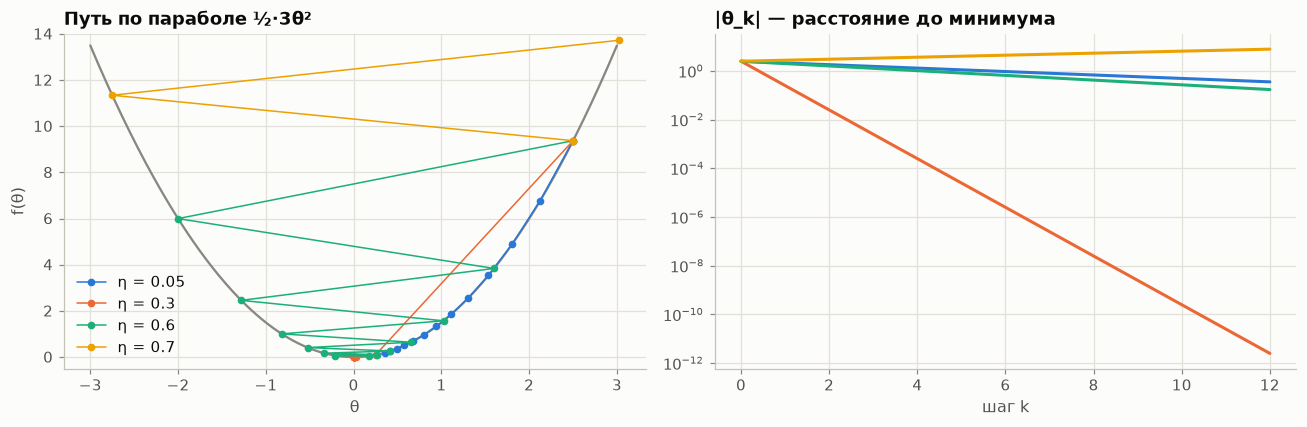

In [3]:
def descend(df, t0, eta, steps):
    ts = [t0]
    for _ in range(steps):
        ts.append(ts[-1] - eta * df(ts[-1]))
    return np.array(ts)


parab, dparab = (lambda t: 1.5 * t**2), (lambda t: 3 * t)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
grid = np.linspace(-3, 3, 400)
axes[0].plot(grid, parab(grid), color="#898781", lw=1.5)
for eta in (0.05, 0.3, 0.6, 0.7):
    ts = descend(dparab, 2.5, eta, 12)
    ts_vis = ts[np.abs(ts) < 3.2]
    axes[0].plot(ts_vis, parab(ts_vis), marker="o", ms=4, lw=1, label=f"η = {eta}")
    axes[1].semilogy(np.abs(ts) + 1e-16, label=f"η = {eta}")
axes[0].set(title="Путь по параболе ½·3θ²", xlabel="θ", ylabel="f(θ)", ylim=(-0.5, 14))
axes[1].set(title="|θ_k| — расстояние до минимума", xlabel="шаг k")
axes[0].legend()
plt.tight_layout()
plt.show()

Для параболы $\theta_{k+1} = (1 - 3\eta)\,\theta_k$: при $\eta = 1/3$ — минимум за шаг,
при $\eta > 2/3$ — расходимость. Проверьте на графике справа: линия η = 0.7 растёт.

## 3. Шаг Ньютона

In [4]:
t = 2.0
print("Ньютон на функции с волной:")
for k in range(6):
    h = d2f(t)
    t = t - df(t) / h if h > 0 else t - 0.1 * df(t)
    print(f"  шаг {k + 1}: θ = {t: .8f}, f'(θ) = {df(t): .2e}")

t = 2.0
for _ in range(6):
    t = t - 0.1 * df(t)
print(f"Градиентный спуск (η = 0.1) за те же 6 шагов: θ = {t:.6f}, f'(θ) = {df(t):.2e}")

Ньютон на функции с волной:
  шаг 1: θ =  0.38967718, f'(θ) =  2.34e+00
  шаг 2: θ =  0.15546106, f'(θ) =  3.15e+00
  шаг 3: θ = -0.15913740, f'(θ) =  2.19e+00
  шаг 4: θ = -0.46566078, f'(θ) = -8.78e-01
  шаг 5: θ = -0.39164417, f'(θ) = -1.81e-02
  шаг 6: θ = -0.39004151, f'(θ) = -1.34e-05
Градиентный спуск (η = 0.1) за те же 6 шагов: θ = 1.016306, f'(θ) = 6.18e-02


## 4. Два параметра: подгонка прямой

$f(a, b) = \frac{1}{2n}\sum (y_i - a x_i - b)^2$. Градиент:
$\partial f/\partial a = -\frac1n \sum r_i x_i$, $\partial f/\partial b = -\frac1n\sum r_i$.

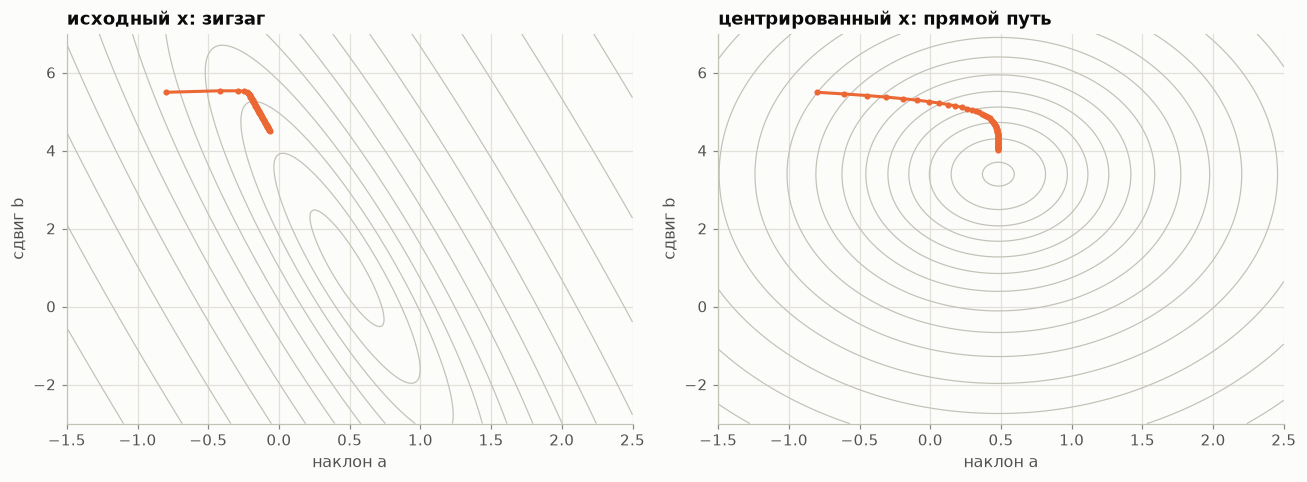

Метод наименьших квадратов: a = 0.4812, b = 0.9853
Спуск, 5000 шагов: [0.4812 0.9853]


In [5]:
X, y = datasets.regression_1d(kind="linear", n=30, noise=0.6, seed=3)
x = X[:, 0]


def gd_line(x, y, eta, steps, a=-0.8, b=5.5):
    path = [(a, b)]
    for _ in range(steps):
        r = y - (a * x + b)
        a, b = a + eta * np.mean(r * x), b + eta * np.mean(r)
        path.append((a, b))
    return np.array(path)


A, B = np.meshgrid(np.linspace(-1.5, 2.5, 200), np.linspace(-3, 7, 200))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, xx, title in [(axes[0], x, "исходный x: зигзаг"), (axes[1], x - x.mean(), "центрированный x: прямой путь")]:
    Z = np.mean((y[None, None, :] - (A[..., None] * xx[None, None, :] + B[..., None])) ** 2, axis=-1) / 2
    ax.contour(A, B, np.log1p(Z), levels=14, colors="#c3c2b7", linewidths=0.8)
    path = gd_line(xx, y, eta=0.02, steps=60)
    ax.plot(path[:, 0], path[:, 1], marker="o", ms=3, color="#eb6834")
    ax.set(title=title, xlabel="наклон a", ylabel="сдвиг b")
plt.tight_layout()
plt.show()

a_ls, b_ls = np.polyfit(x, y, 1)
print(f"Метод наименьших квадратов: a = {a_ls:.4f}, b = {b_ls:.4f}")
print("Спуск, 5000 шагов:", gd_line(x, y, eta=0.02, steps=5000)[-1].round(4))

## 5. Спуск для константы = «прибавь долю среднего остатка»

In [6]:
c, eta = 0.0, 0.5
for k in range(8):
    c = c + eta * np.mean(y - c)
    print(f"шаг {k + 1}: c = {c:.5f}")
print("среднее y =", y.mean())

шаг 1: c = 1.69992
шаг 2: c = 2.54988
шаг 3: c = 2.97486
шаг 4: c = 3.18735
шаг 5: c = 3.29360
шаг 6: c = 3.34672
шаг 7: c = 3.37328
шаг 8: c = 3.38656
среднее y = 3.39984458471818


## Упражнения

1. Найдите аналитически наибольший η, при котором спуск по $f(\theta) = \tfrac{a}{2}\theta^2$ сходится. Проверьте численно при a = 3.
2. Сколько шагов нужно спуску с η = 0.02 в задаче о прямой, чтобы MSE отличалась от оптимума меньше чем на 1e-4? А при центрированном x?
3. Реализуйте спуск с «затуханием» темпа $\eta_k = \eta_0/(1+k/10)$ для функции $|\theta|$. Исчезает ли дребезжание?

Решения: `python lessons/lesson_1_3/exercises/solutions.py`.